# House Price Prediction

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

Loading the dataset:

In [3]:
file_name = "train.csv"
df_house_prices = pd.read_csv(file_name)
df_house_prices

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


Building a correlation matrix:

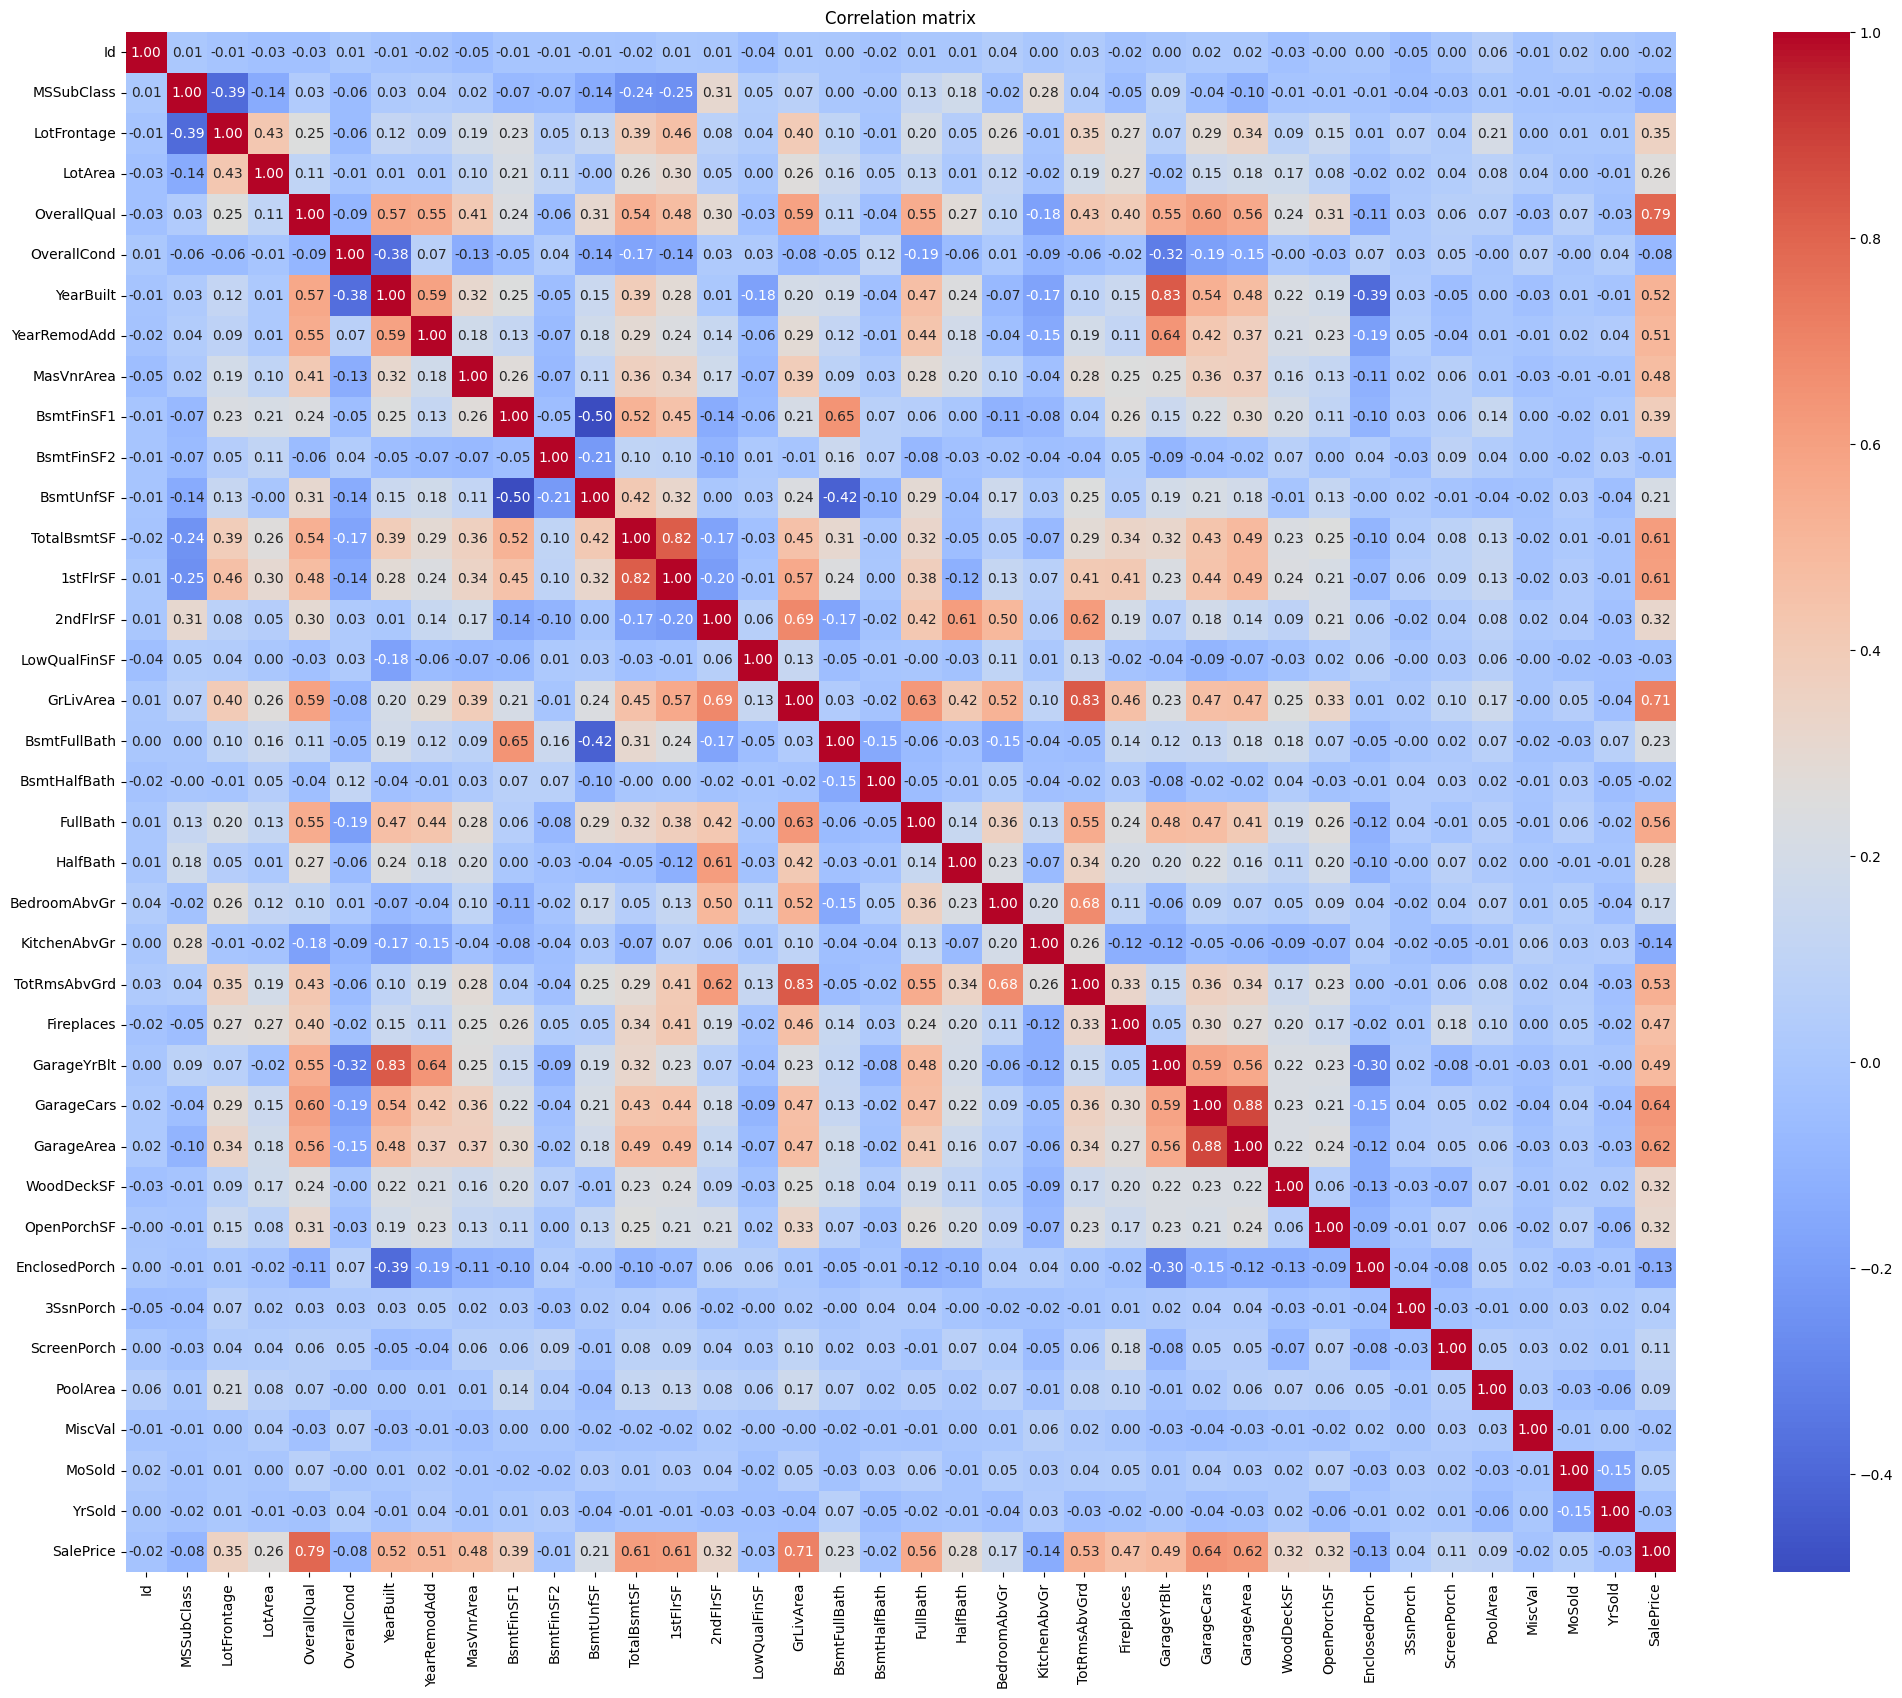

In [4]:
plt.figure(figsize=(25,20))
sns.heatmap(df_house_prices.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

For analysis and model building, we selected 15 features that best reflect property values. The selection process was based not only on their correlation with the target variable, but also on market logic and potential non-linear relationships. The chosen features include house quality and condition (OverallQual, KitchenQual, ExterQual, BsmtQual, YearBuilt, YearRemodAdd), living area size (GrLivArea, 1stFlrSF, TotalBsmtSF, GarageArea), amenities (FullBath, GarageCars, Fireplaces), and external factors (LotArea, Neighborhood). This feature set accounts for both statistically strong relationships and critical non-linear factors that influence pricing.

Features selection:

In [5]:
selected_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "YearBuilt", "YearRemodAdd", "KitchenQual",
    "Fireplaces", "Neighborhood", "LotArea", "ExterQual", "BsmtQual"
]

Performing Exploratory Data Analysis (EDA) on a dataset:

In [6]:
df_selected_features = df_house_prices[selected_features + ["SalePrice"]]
df_selected_features

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,KitchenQual,Fireplaces,Neighborhood,LotArea,ExterQual,BsmtQual,SalePrice
0,7,1710,2,548,856,856,2,2003,2003,Gd,0,CollgCr,8450,Gd,Gd,208500
1,6,1262,2,460,1262,1262,2,1976,1976,TA,1,Veenker,9600,TA,Gd,181500
2,7,1786,2,608,920,920,2,2001,2002,Gd,1,CollgCr,11250,Gd,Gd,223500
3,7,1717,3,642,756,961,1,1915,1970,Gd,1,Crawfor,9550,TA,TA,140000
4,8,2198,3,836,1145,1145,2,2000,2000,Gd,1,NoRidge,14260,Gd,Gd,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,2,1999,2000,TA,1,Gilbert,7917,TA,Gd,175000
1456,6,2073,2,500,1542,2073,2,1978,1988,TA,2,NWAmes,13175,TA,Gd,210000
1457,7,2340,1,252,1152,1188,2,1941,2006,Gd,2,Crawfor,9042,Ex,TA,266500
1458,5,1078,1,240,1078,1078,1,1950,1996,Gd,0,NAmes,9717,TA,TA,142125


In [7]:
df_selected_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   GarageCars    1460 non-null   int64 
 3   GarageArea    1460 non-null   int64 
 4   TotalBsmtSF   1460 non-null   int64 
 5   1stFlrSF      1460 non-null   int64 
 6   FullBath      1460 non-null   int64 
 7   YearBuilt     1460 non-null   int64 
 8   YearRemodAdd  1460 non-null   int64 
 9   KitchenQual   1460 non-null   object
 10  Fireplaces    1460 non-null   int64 
 11  Neighborhood  1460 non-null   object
 12  LotArea       1460 non-null   int64 
 13  ExterQual     1460 non-null   object
 14  BsmtQual      1423 non-null   object
 15  SalePrice     1460 non-null   int64 
dtypes: int64(12), object(4)
memory usage: 182.6+ KB


In [8]:
df_selected_features.isnull().sum()

OverallQual      0
GrLivArea        0
GarageCars       0
GarageArea       0
TotalBsmtSF      0
1stFlrSF         0
FullBath         0
YearBuilt        0
YearRemodAdd     0
KitchenQual      0
Fireplaces       0
Neighborhood     0
LotArea          0
ExterQual        0
BsmtQual        37
SalePrice        0
dtype: int64

In [9]:
df_selected_features.describe()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,Fireplaces,LotArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,472.980137,1057.429452,1162.626712,1.565068,1971.267808,1984.865753,0.613014,10516.828082,180921.195890
std,1.382997,525.480383,0.747315,213.804841,438.705324,386.587738,0.550916,30.202904,20.645407,0.644666,9981.264932,79442.502883
min,1.000000,334.000000,0.000000,0.000000,0.000000,334.000000,0.000000,1872.000000,1950.000000,0.000000,1300.000000,34900.000000
25%,5.000000,1129.500000,1.000000,334.500000,795.750000,882.000000,1.000000,1954.000000,1967.000000,0.000000,7553.500000,129975.000000
50%,6.000000,1464.000000,2.000000,480.000000,991.500000,1087.000000,2.000000,1973.000000,1994.000000,1.000000,9478.500000,163000.000000
75%,7.000000,1776.750000,2.000000,576.000000,1298.250000,1391.250000,2.000000,2000.000000,2004.000000,1.000000,11601.500000,214000.000000
max,10.000000,5642.000000,4.000000,1418.000000,6110.000000,4692.000000,3.000000,2010.000000,2010.000000,3.000000,215245.000000,755000.000000


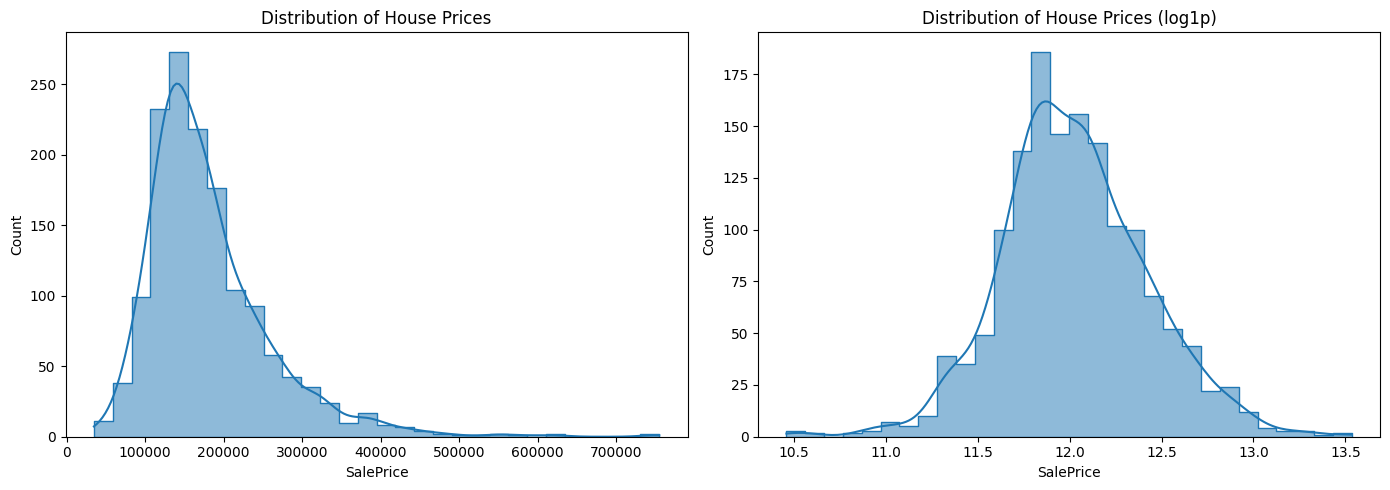

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["SalePrice"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of House Prices")

sns.histplot(np.log1p(df_house_prices["SalePrice"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of House Prices (log1p)")

plt.tight_layout()
plt.show()

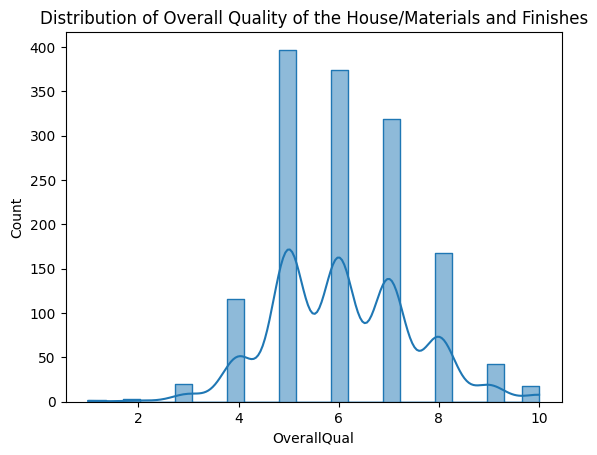

In [11]:
sns.histplot(df_selected_features["OverallQual"], kde=True, element="step")
plt.title("Distribution of Overall Quality of the House/Materials and Finishes")
plt.show()

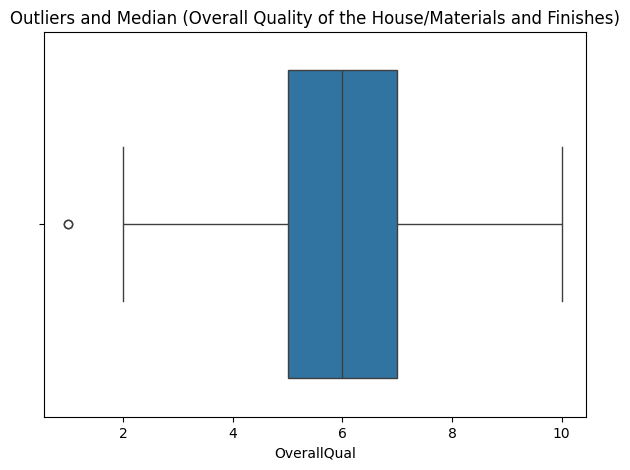

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df_selected_features["OverallQual"])
plt.title("Outliers and Median (Overall Quality of the House/Materials and Finishes)")
plt.show()

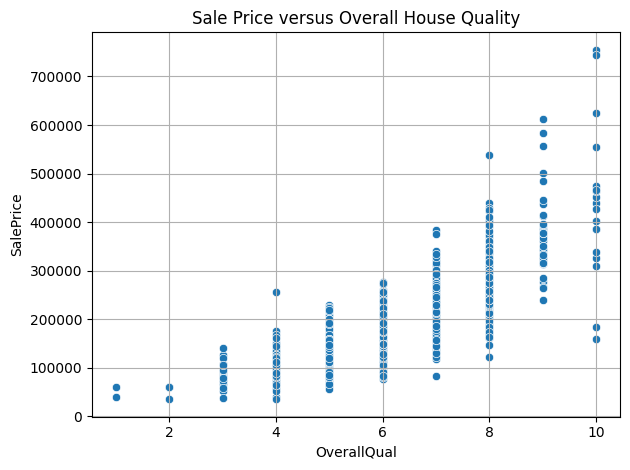

In [13]:
sns.scatterplot(data=df_selected_features, x="OverallQual", y="SalePrice")
plt.title("Sale Price versus Overall House Quality")
plt.grid(True)
plt.tight_layout()
plt.show()

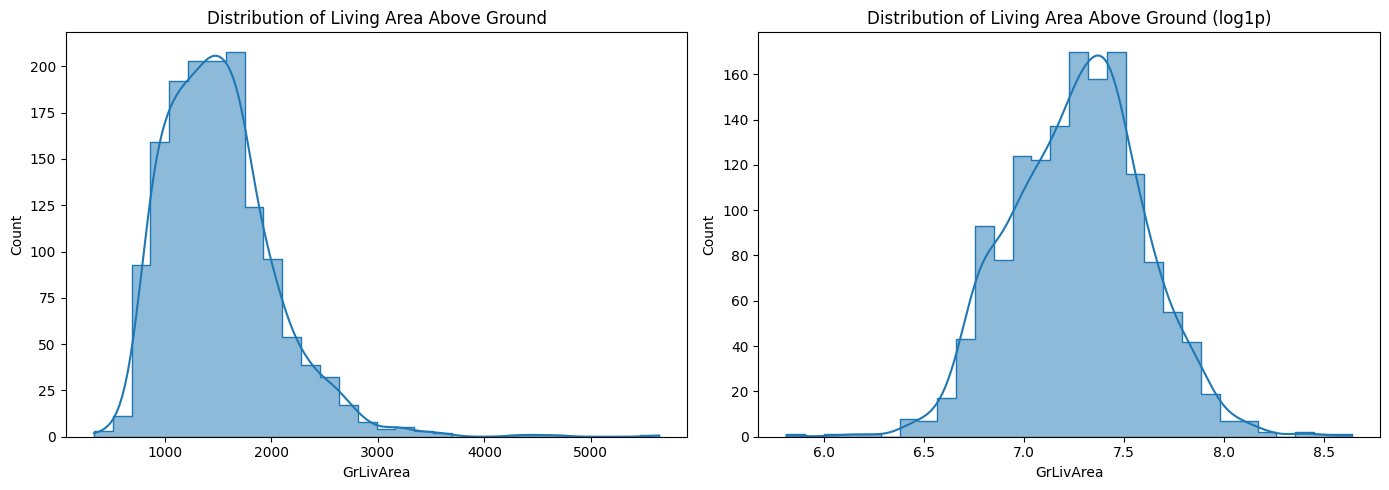

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["GrLivArea"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of Living Area Above Ground")

sns.histplot(np.log1p(df_house_prices["GrLivArea"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of Living Area Above Ground (log1p)")

plt.tight_layout()
plt.show()

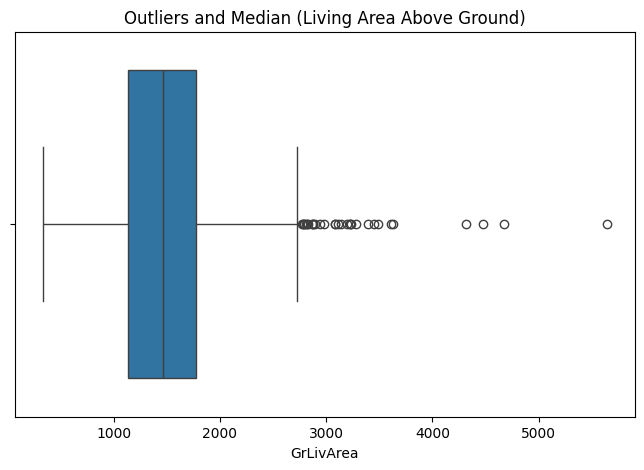

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_selected_features["GrLivArea"])
plt.title("Outliers and Median (Living Area Above Ground)")
plt.show()

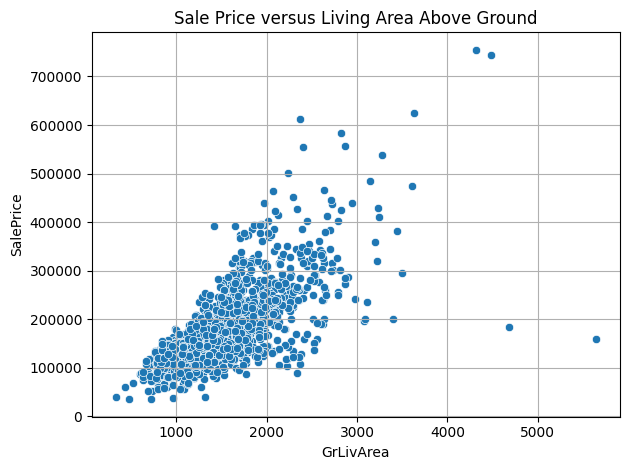

In [16]:
sns.scatterplot(data=df_selected_features, x="GrLivArea", y="SalePrice")
plt.title("Sale Price versus Living Area Above Ground")
plt.grid(True)
plt.tight_layout()
plt.show()

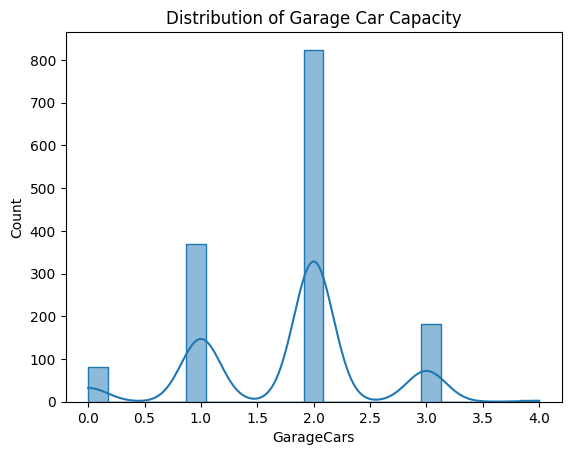

In [17]:
sns.histplot(df_selected_features["GarageCars"], kde=True, element="step")
plt.title("Distribution of Garage Car Capacity")
plt.show()

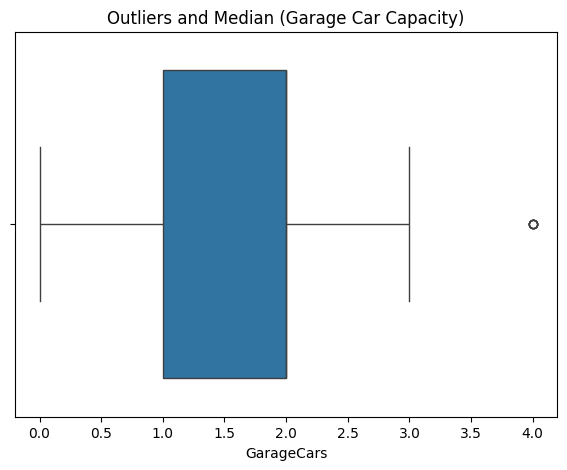

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df_selected_features["GarageCars"])
plt.title("Outliers and Median (Garage Car Capacity)")
plt.show()

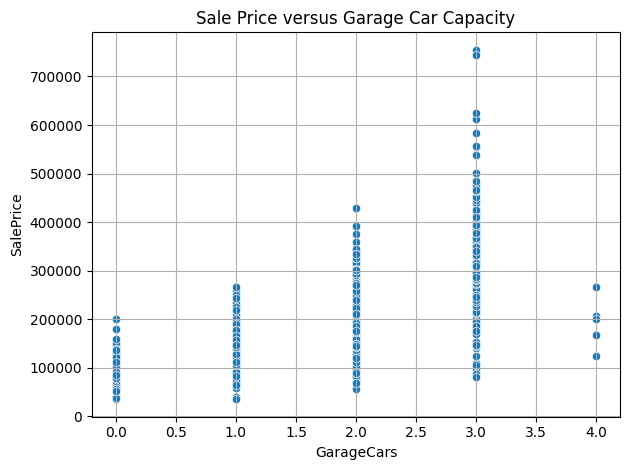

In [19]:
sns.scatterplot(data=df_selected_features, x="GarageCars", y="SalePrice")
plt.title("Sale Price versus Garage Car Capacity")
plt.grid(True)
plt.tight_layout()
plt.show()

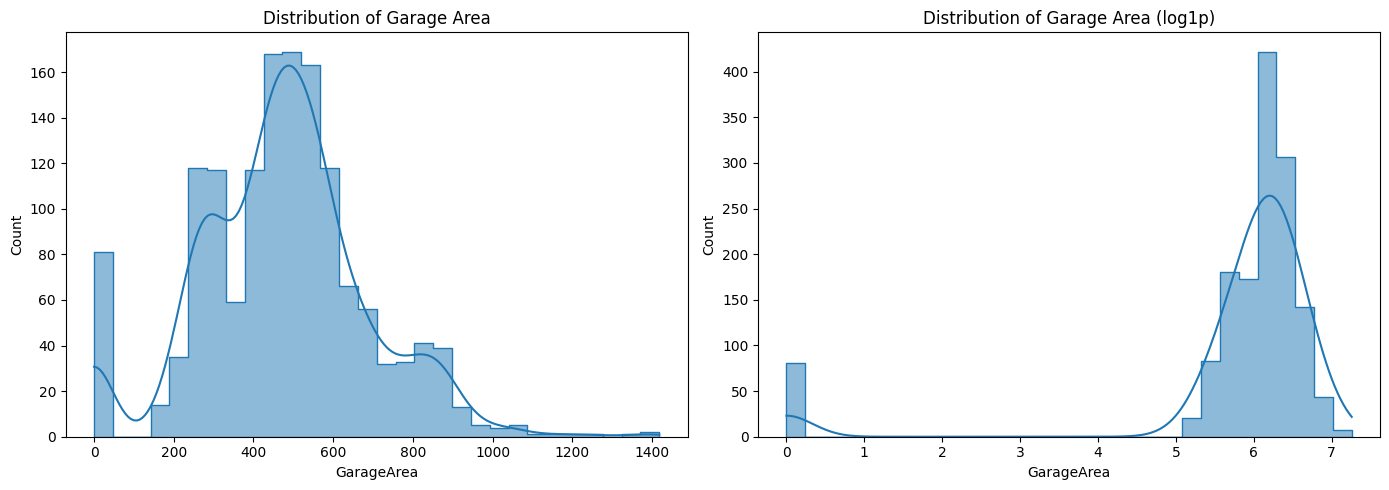

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["GarageArea"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of Garage Area")

sns.histplot(np.log1p(df_house_prices["GarageArea"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of Garage Area (log1p)")

plt.tight_layout()
plt.show()

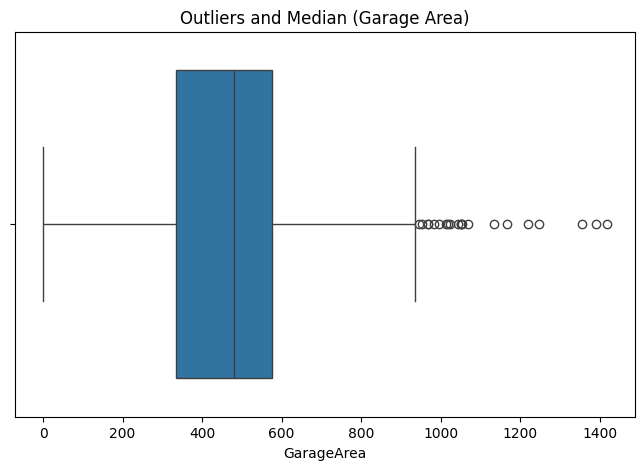

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_selected_features["GarageArea"])
plt.title("Outliers and Median (Garage Area)")
plt.show()

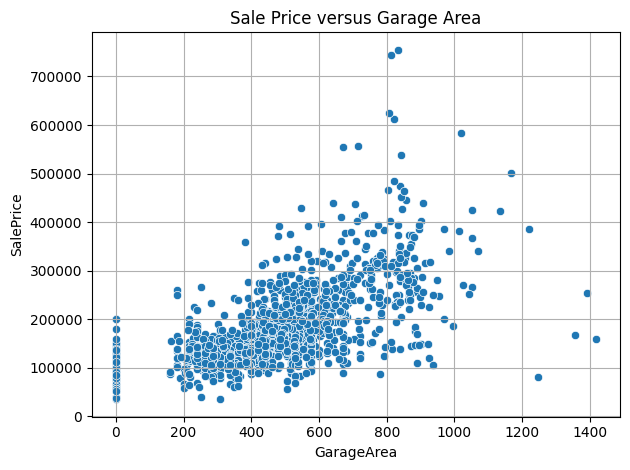

In [22]:
sns.scatterplot(data=df_selected_features, x="GarageArea", y="SalePrice")
plt.title("Sale Price versus Garage Area")
plt.grid(True)
plt.tight_layout()
plt.show()

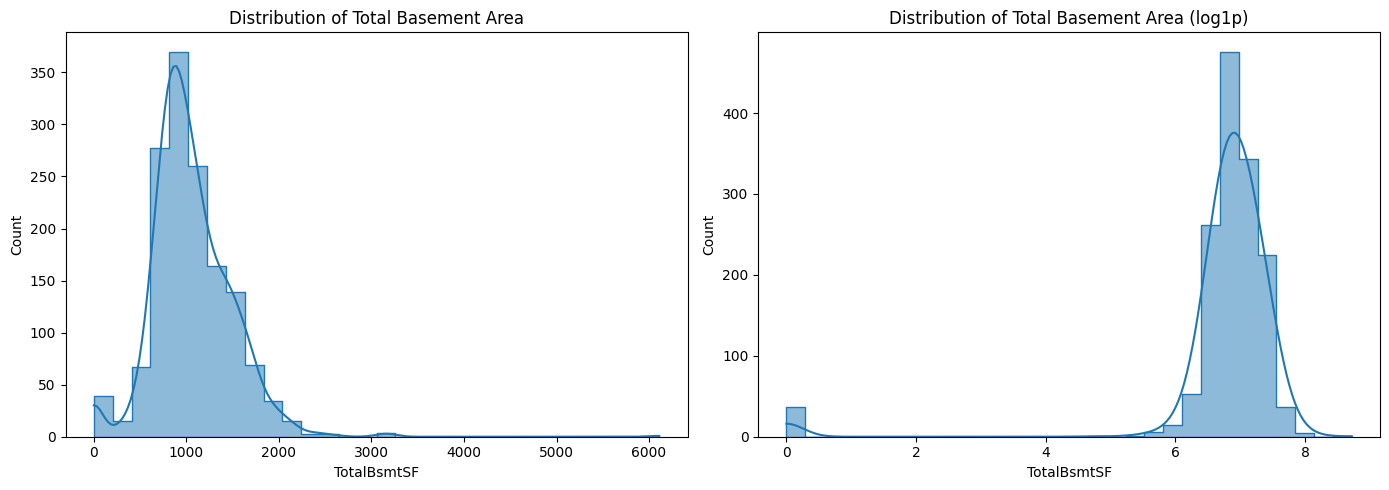

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["TotalBsmtSF"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of Total Basement Area")

sns.histplot(np.log1p(df_house_prices["TotalBsmtSF"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of Total Basement Area (log1p)")

plt.tight_layout()
plt.show()

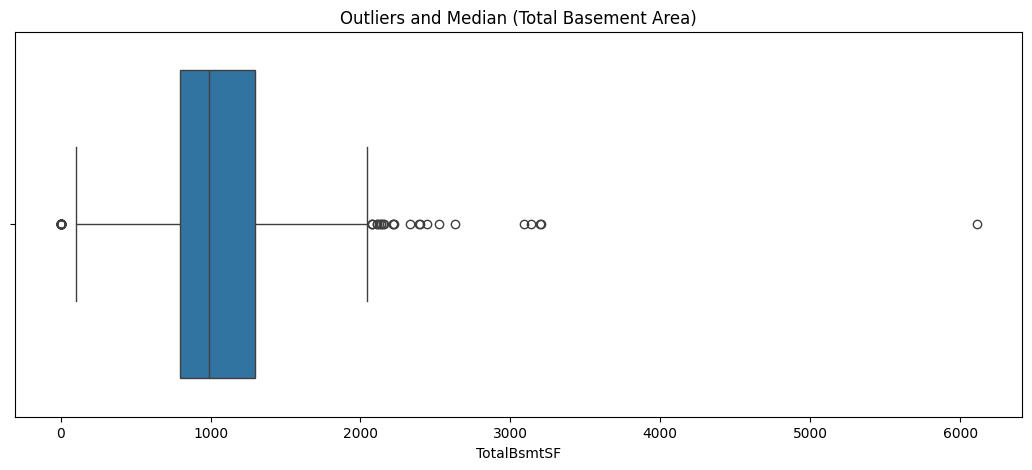

In [24]:
plt.figure(figsize=(13,5))
sns.boxplot(x=df_selected_features["TotalBsmtSF"])
plt.title("Outliers and Median (Total Basement Area)")
plt.show()

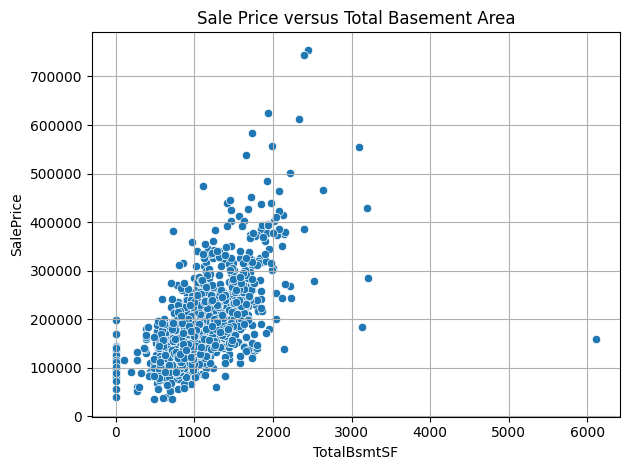

In [25]:
sns.scatterplot(data=df_selected_features, x="TotalBsmtSF", y="SalePrice")
plt.title("Sale Price versus Total Basement Area")
plt.grid(True)
plt.tight_layout()
plt.show()

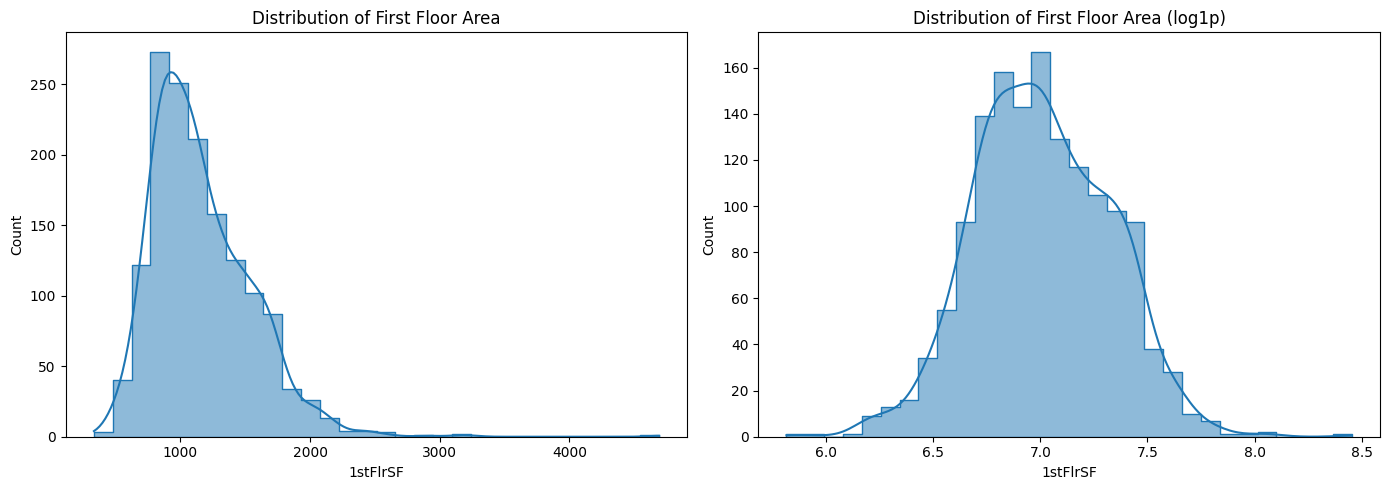

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["1stFlrSF"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of First Floor Area")

sns.histplot(np.log1p(df_house_prices["1stFlrSF"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of First Floor Area (log1p)")

plt.tight_layout()
plt.show()

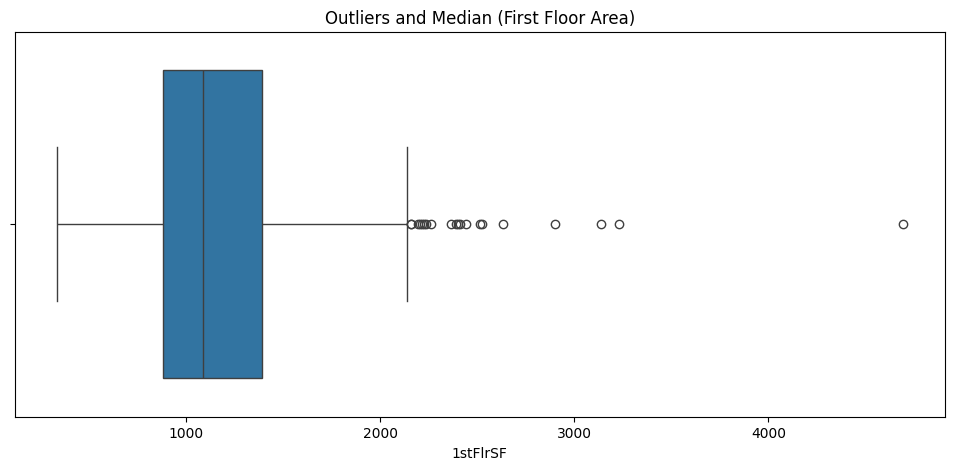

In [27]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df_selected_features["1stFlrSF"])
plt.title("Outliers and Median (First Floor Area)")
plt.show()

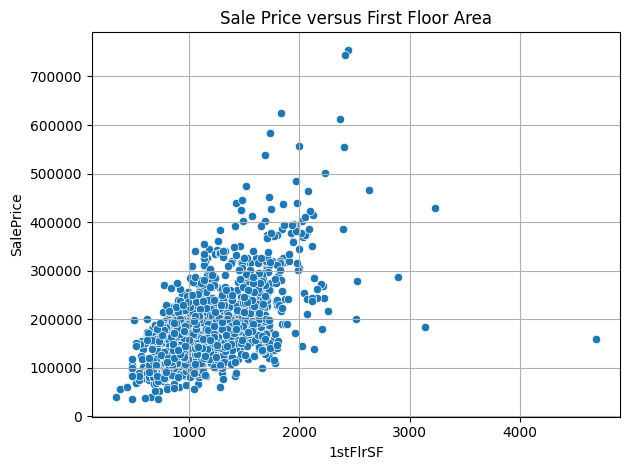

In [28]:
sns.scatterplot(data=df_selected_features, x="1stFlrSF", y="SalePrice")
plt.title("Sale Price versus First Floor Area")
plt.grid(True)
plt.tight_layout()
plt.show()

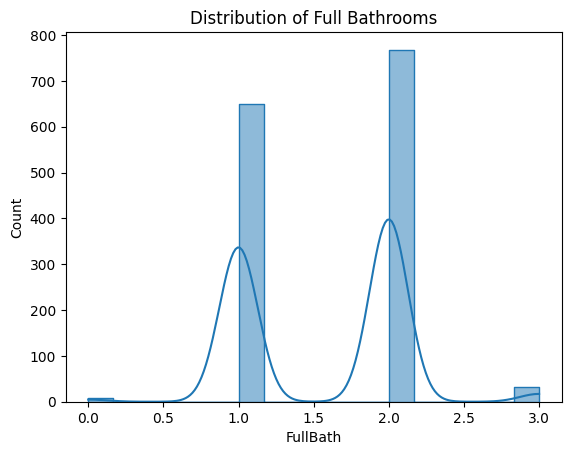

In [29]:
sns.histplot(df_selected_features["FullBath"], kde=True, element="step")
plt.title("Distribution of Full Bathrooms")
plt.show()

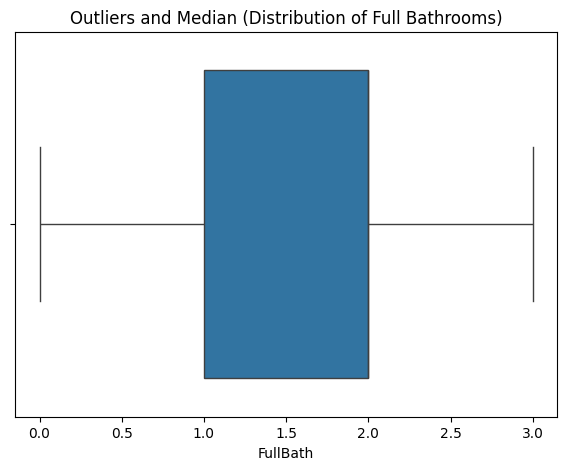

In [30]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df_selected_features["FullBath"])
plt.title("Outliers and Median (Distribution of Full Bathrooms)")
plt.show()

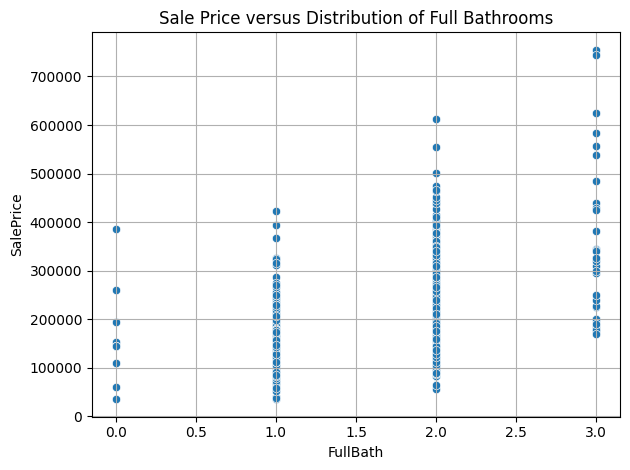

In [31]:
sns.scatterplot(data=df_selected_features, x="FullBath", y="SalePrice")
plt.title("Sale Price versus Distribution of Full Bathrooms")
plt.grid(True)
plt.tight_layout()
plt.show()

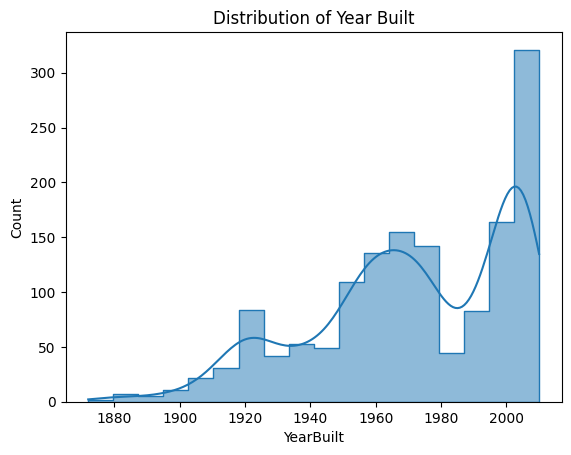

In [32]:
sns.histplot(df_selected_features["YearBuilt"], kde=True, element="step")
plt.title("Distribution of Year Built")
plt.show()

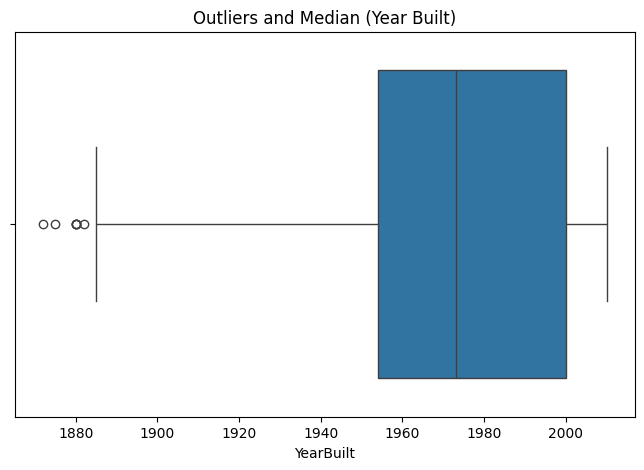

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_selected_features["YearBuilt"])
plt.title("Outliers and Median (Year Built)")
plt.show()

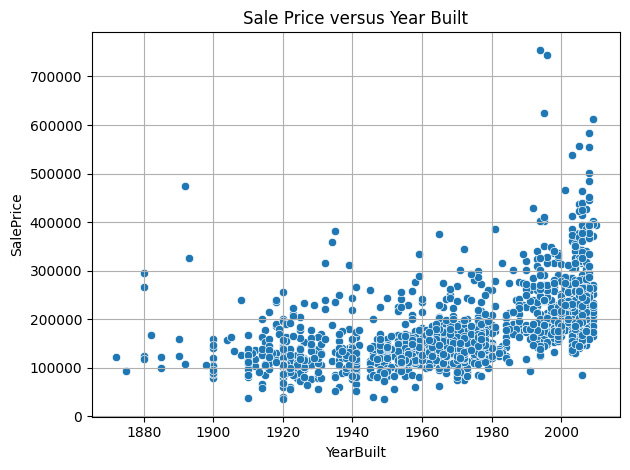

In [34]:
sns.scatterplot(data=df_selected_features, x="YearBuilt", y="SalePrice")
plt.title("Sale Price versus Year Built")
plt.grid(True)
plt.tight_layout()
plt.show()

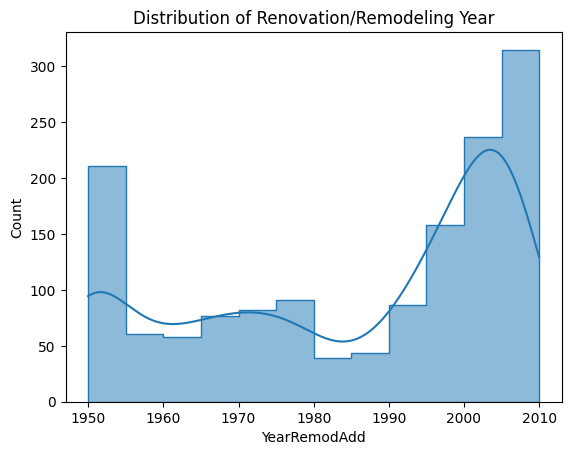

In [35]:
sns.histplot(df_selected_features["YearRemodAdd"], kde=True, element="step")
plt.title("Distribution of Renovation/Remodeling Year")
plt.show()

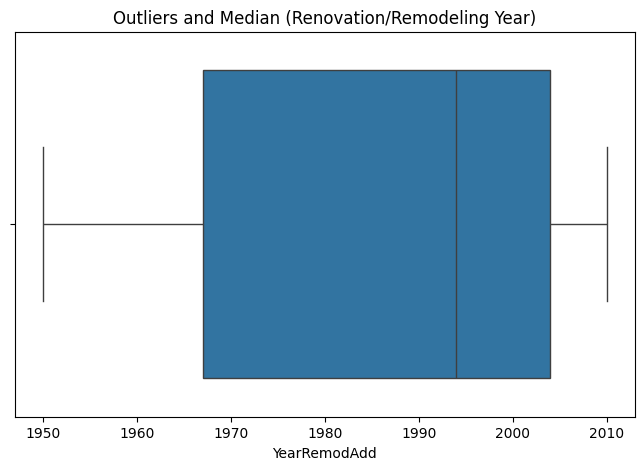

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_selected_features["YearRemodAdd"])
plt.title("Outliers and Median (Renovation/Remodeling Year)")
plt.show()

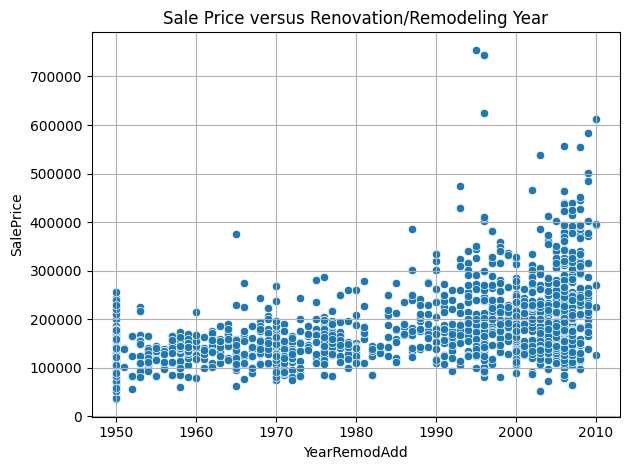

In [37]:
sns.scatterplot(data=df_selected_features, x="YearRemodAdd", y="SalePrice")
plt.title("Sale Price versus Renovation/Remodeling Year")
plt.grid(True)
plt.tight_layout()
plt.show()

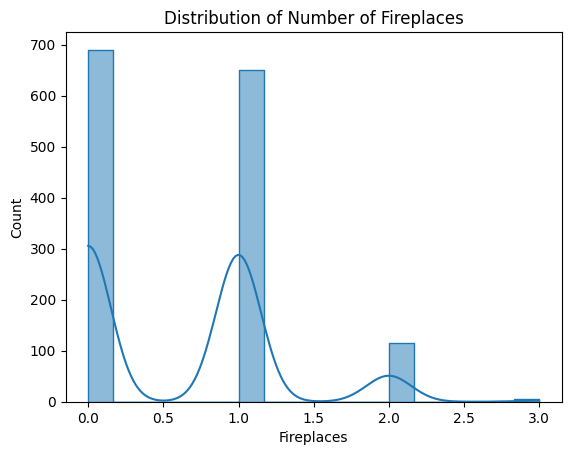

In [38]:
sns.histplot(df_selected_features["Fireplaces"], kde=True, element="step")
plt.title("Distribution of Number of Fireplaces")
plt.show()

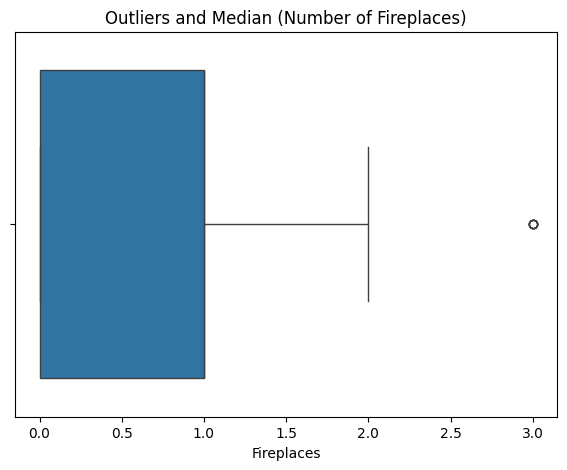

In [39]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df_selected_features["Fireplaces"])
plt.title("Outliers and Median (Number of Fireplaces)")
plt.show()

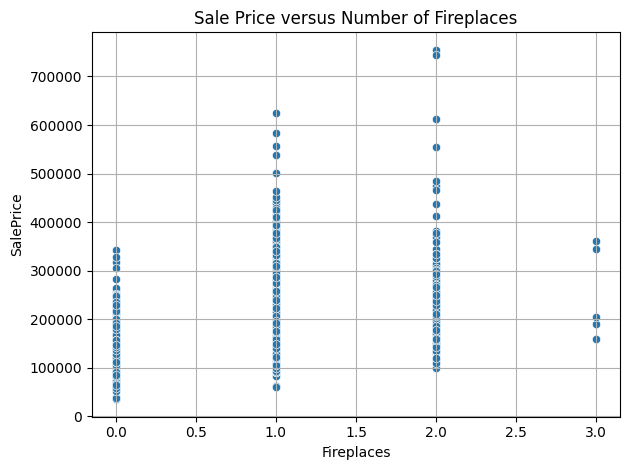

In [40]:
sns.scatterplot(data=df_selected_features, x="Fireplaces", y="SalePrice")
plt.title("Sale Price versus Number of Fireplaces")
plt.grid(True)
plt.tight_layout()
plt.show()

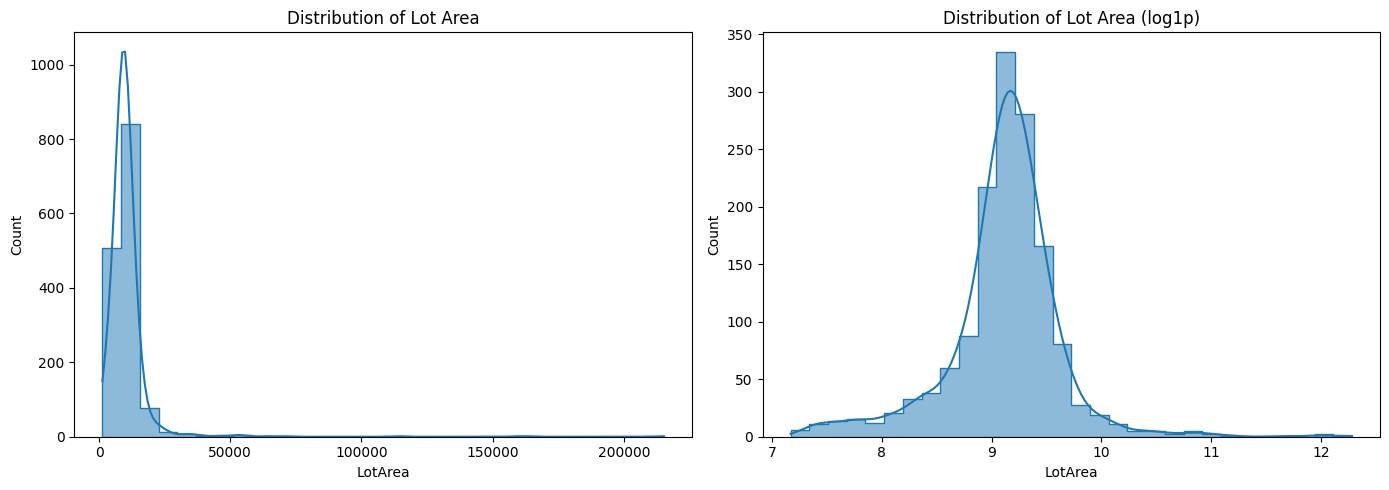

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_house_prices["LotArea"], bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Distribution of Lot Area")

sns.histplot(np.log1p(df_house_prices["LotArea"]), bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Distribution of Lot Area (log1p)")

plt.tight_layout()
plt.show()

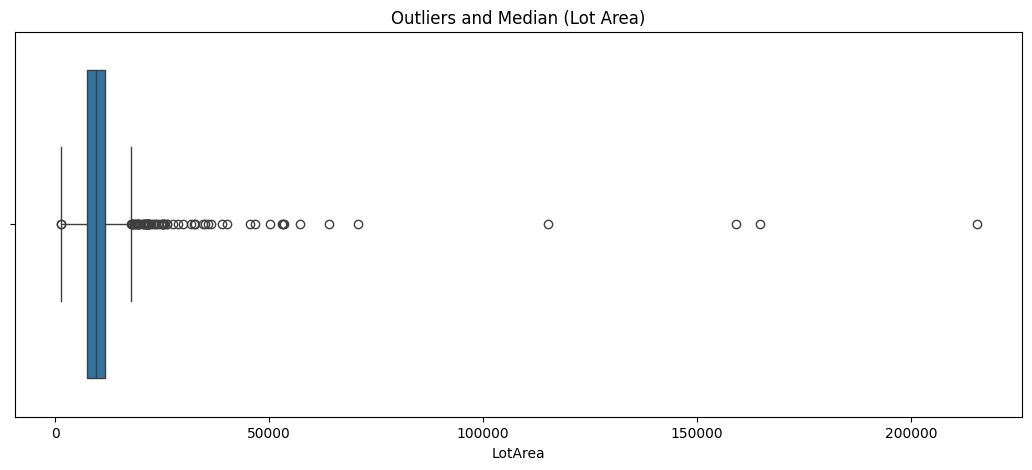

In [42]:
plt.figure(figsize=(13,5))
sns.boxplot(x=df_selected_features["LotArea"])
plt.title("Outliers and Median (Lot Area)")
plt.show()

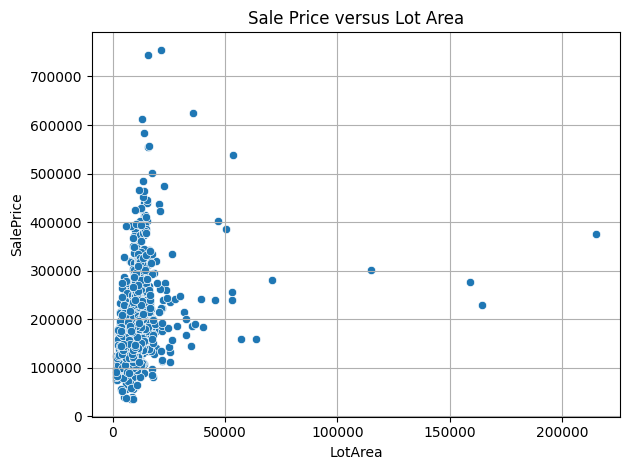

In [43]:
sns.scatterplot(data=df_selected_features, x="LotArea", y="SalePrice")
plt.title("Sale Price versus Lot Area")
plt.grid(True)
plt.tight_layout()
plt.show()

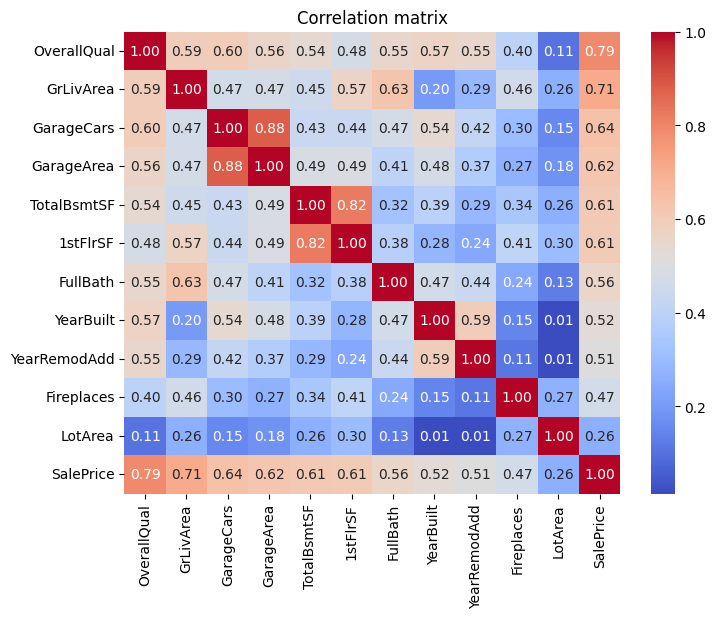

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df_selected_features.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

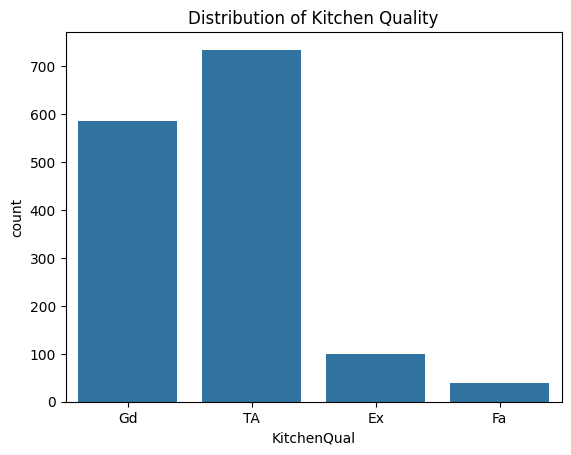

In [45]:
sns.countplot(data=df_selected_features, x="KitchenQual")
plt.title("Distribution of Kitchen Quality")
plt.show()

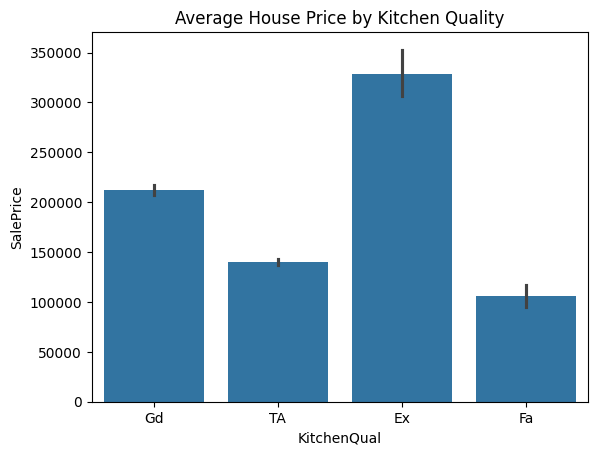

In [46]:
sns.barplot(data=df_selected_features, x="KitchenQual", y="SalePrice", estimator="mean")
plt.title("Average House Price by Kitchen Quality")
plt.show()

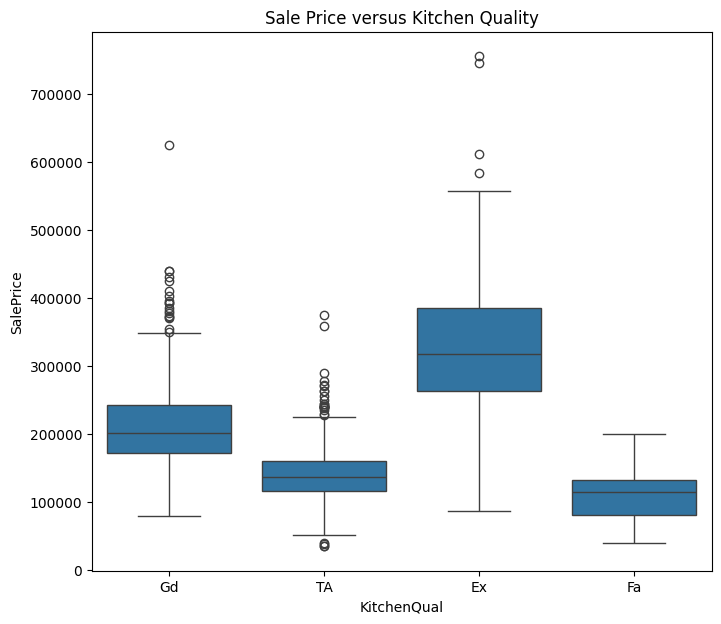

In [47]:
plt.figure(figsize=(8,7))
sns.boxplot(data=df_selected_features, x="KitchenQual", y="SalePrice")
plt.title("Sale Price versus Kitchen Quality")
plt.show()

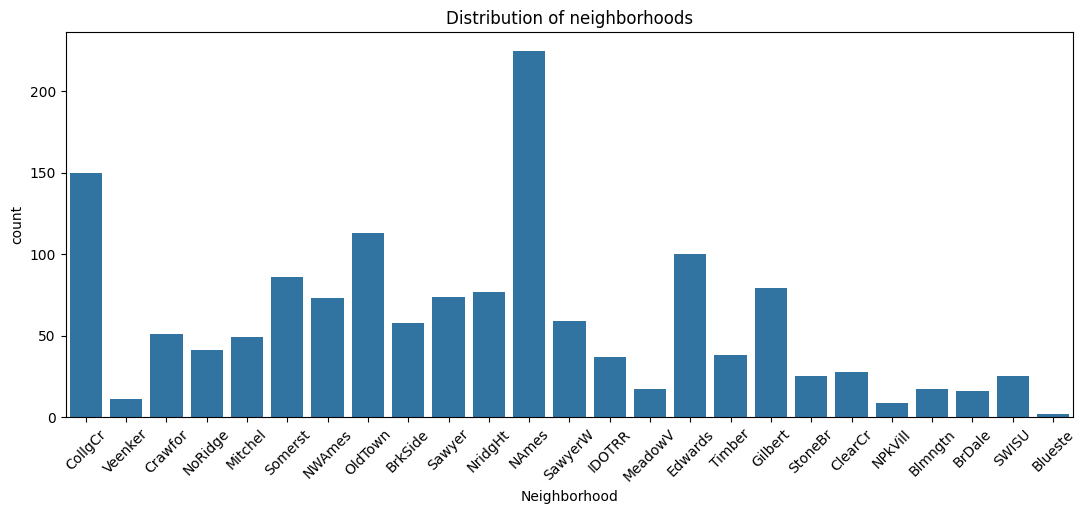

In [48]:
plt.figure(figsize=(13,5))
sns.countplot(data=df_selected_features, x="Neighborhood")
plt.title("Distribution of neighborhoods")
plt.xticks(rotation=45)
plt.show()

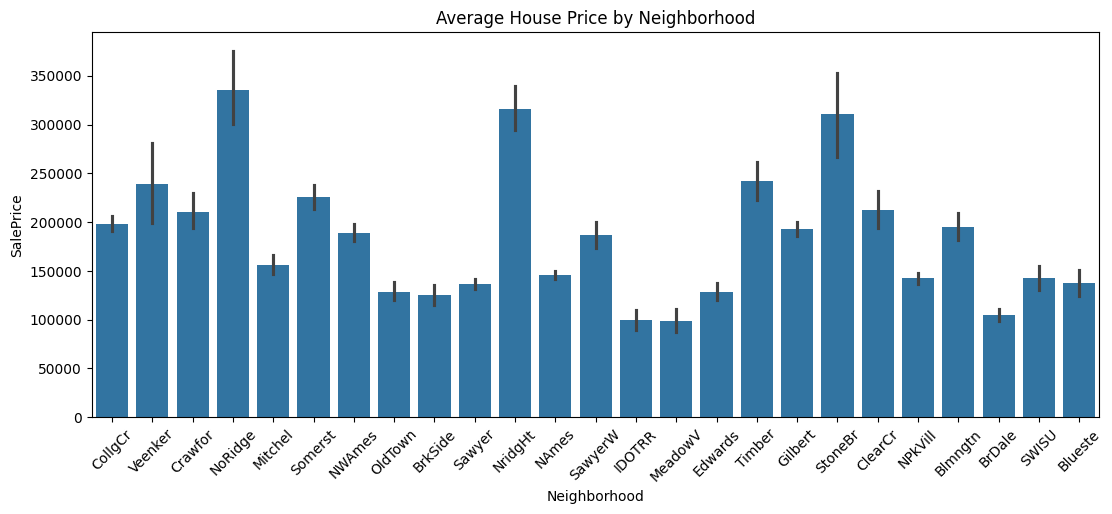

In [49]:
plt.figure(figsize=(13,5))
sns.barplot(data=df_selected_features, x="Neighborhood", y="SalePrice", estimator="mean")
plt.title("Average House Price by Neighborhood")
plt.xticks(rotation=45)
plt.show()

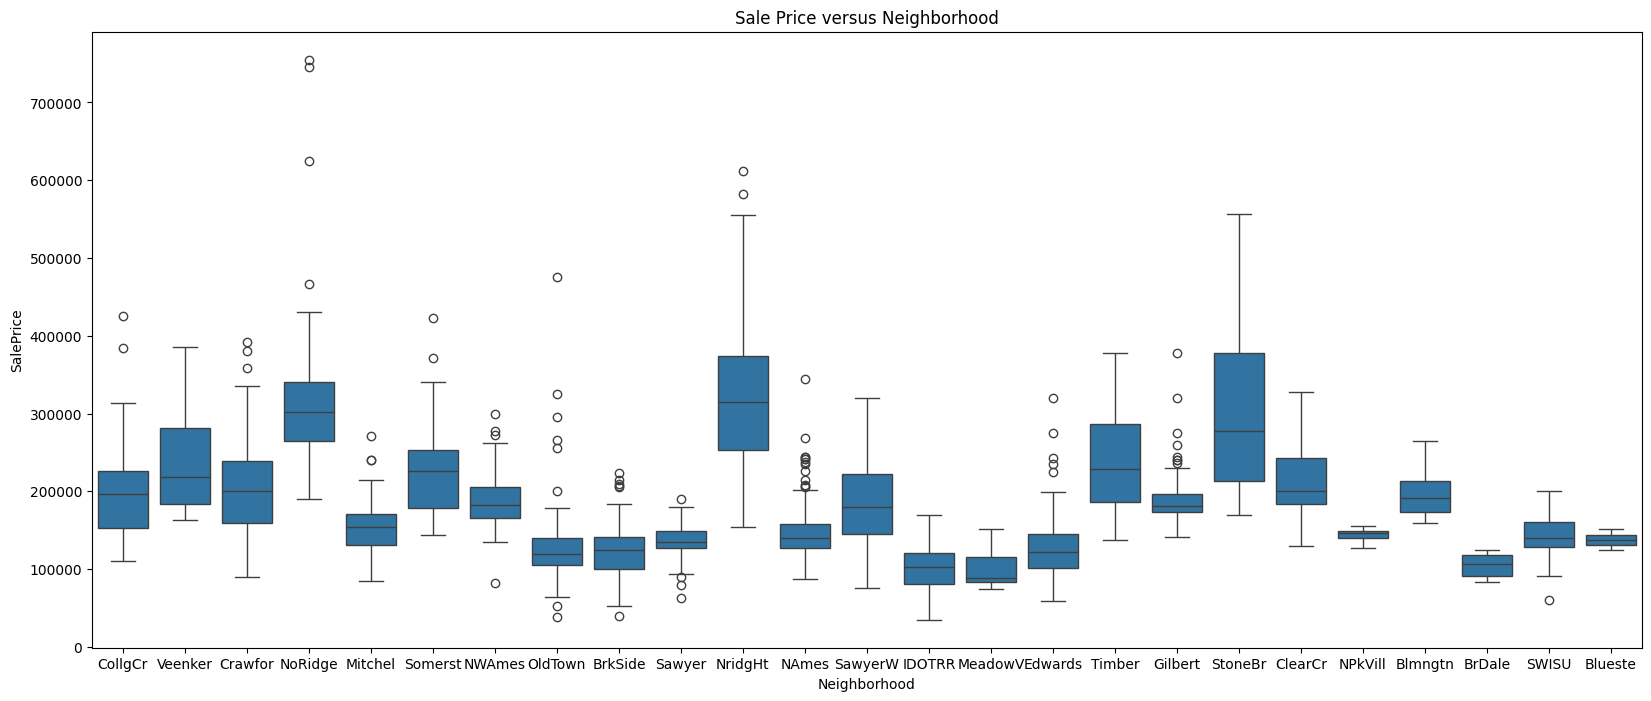

In [50]:
plt.figure(figsize=(20,8))
sns.boxplot(data=df_selected_features, x="Neighborhood", y="SalePrice")
plt.title("Sale Price versus Neighborhood")
plt.show()

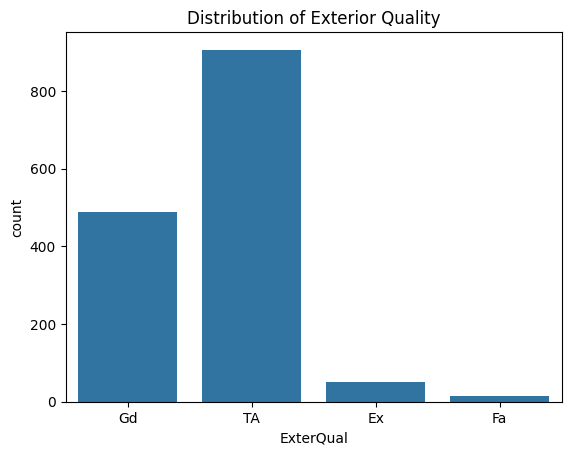

In [51]:
sns.countplot(data=df_selected_features, x="ExterQual")
plt.title("Distribution of Exterior Quality")
plt.show()

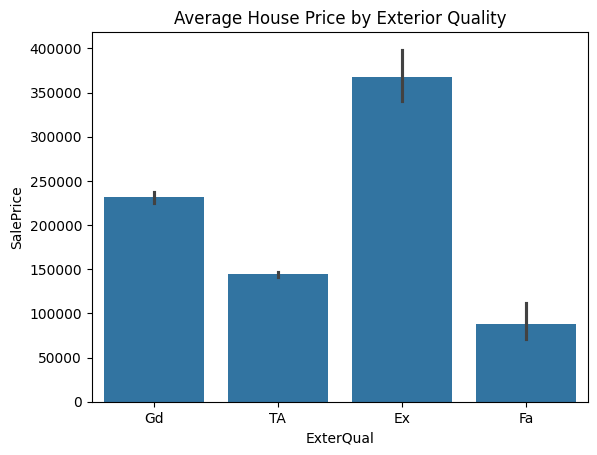

In [52]:
sns.barplot(data=df_selected_features, x="ExterQual", y="SalePrice", estimator="mean")
plt.title("Average House Price by Exterior Quality")
plt.show()

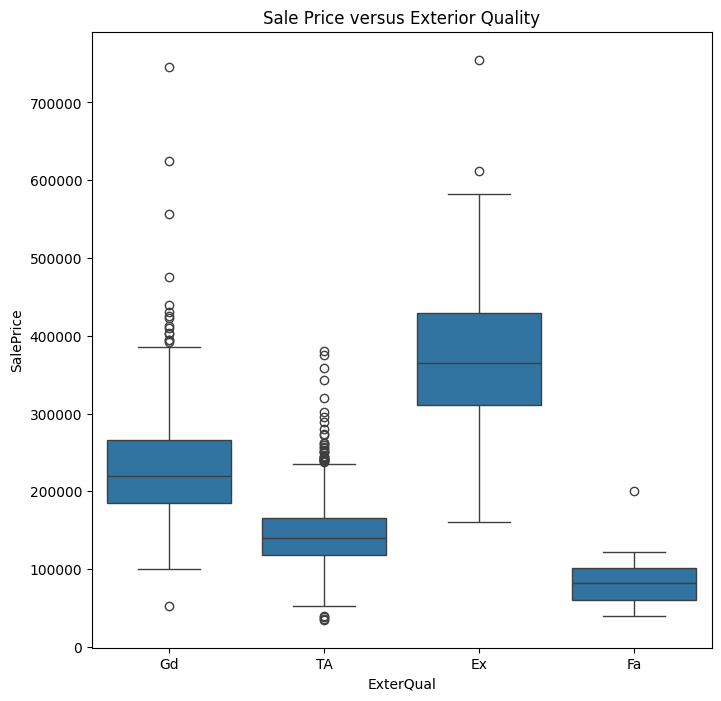

In [53]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df_selected_features, x="ExterQual", y="SalePrice")
plt.title("Sale Price versus Exterior Quality")
plt.show()

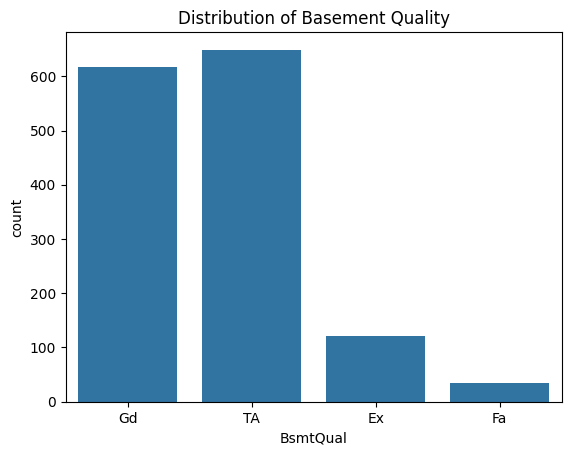

In [54]:
sns.countplot(data=df_selected_features, x="BsmtQual")
plt.title("Distribution of Basement Quality")
plt.show()

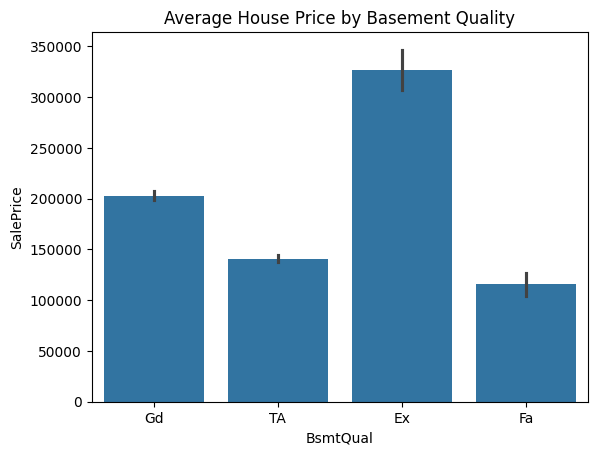

In [55]:
sns.barplot(data=df_selected_features, x="BsmtQual", y="SalePrice", estimator="mean")
plt.title("Average House Price by Basement Quality")
plt.show()

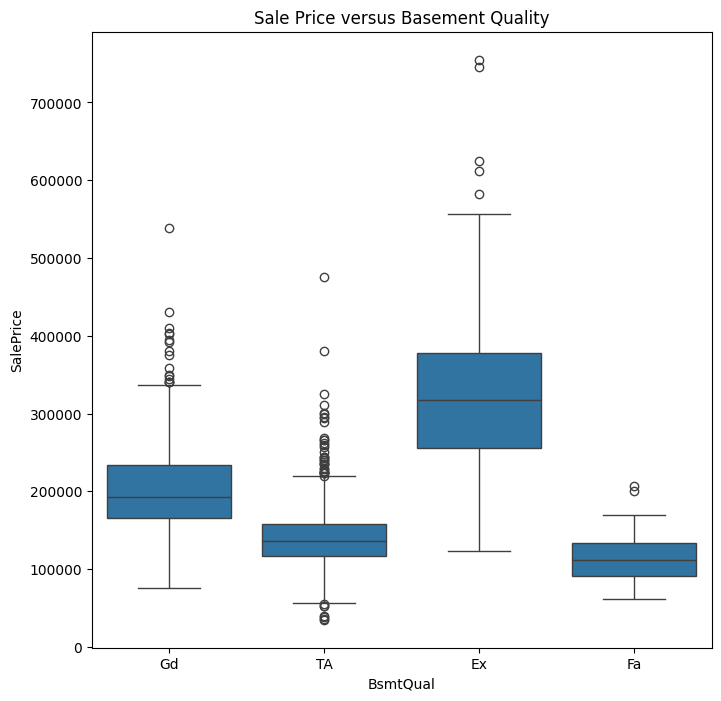

In [56]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df_selected_features, x="BsmtQual", y="SalePrice")
plt.title("Sale Price versus Basement Quality")
plt.show()

Implementation of a function for model training and evaluation for a house price prediction task:

In [57]:
def knn_experiment(df, title="Experiment"):

    X = df.drop(columns=["SalePrice"])
    y = np.log1p(df["SalePrice"])  

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=30
    )

    num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_features_ordinal = ["ExterQual", "BsmtQual", "KitchenQual"]
    cat_features_onehot = ["Neighborhood"]

    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    quality_order = ["Po", "Fa", "TA", "Gd", "Ex"]
    categories = [quality_order] * len(cat_features_ordinal)

    ord_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=categories))
    ])

    onehot_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_transformer, num_features),
            ("ord", ord_transformer, cat_features_ordinal),
            ("cat", onehot_transformer, cat_features_onehot)
        ]
    )

    model = Lasso(max_iter=10000, random_state=30)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    param_grid = {
        "model__alpha": np.logspace(-3, 1, 20)
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"\n===== {title} =====")
    print("Best parameters:", grid_search.best_params_)

    y_pred_log = grid_search.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    print("MAE: ", mean_absolute_error(y_test_real, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_pred)))

    plt.figure(figsize=(7, 6))
    plt.scatter(y_test_real, y_pred, alpha=0.6)
    plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], "r--")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{title}: Comparison of Predicted and Actual Prices")
    plt.show()

    return grid_search

For the Lasso model, the key hyperparameter is alpha, which represents the regularization strength. It controls the balance between model accuracy and complexity:
- At small alpha values, regularization is weak, and coefficients face minimal penalties, which can lead to overfitting.
- At large alpha values, regularization is strong, forcing coefficients toward zero, making the model simpler but potentially leading to underfitting.

We tuned alpha in the range from 0.001 to 10 using np.logspace(-3, 1, 20). This approach generates values on a logarithmic scale, allowing us to explore both very small and large alpha values while examining the lower range more closely where the model is most sensitive.

Experiment before feature engineering:


===== Before FE =====
Best parameters: {'model__alpha': np.float64(0.001)}
MAE:  19407.86954144498
RMSE: 27303.91033995655


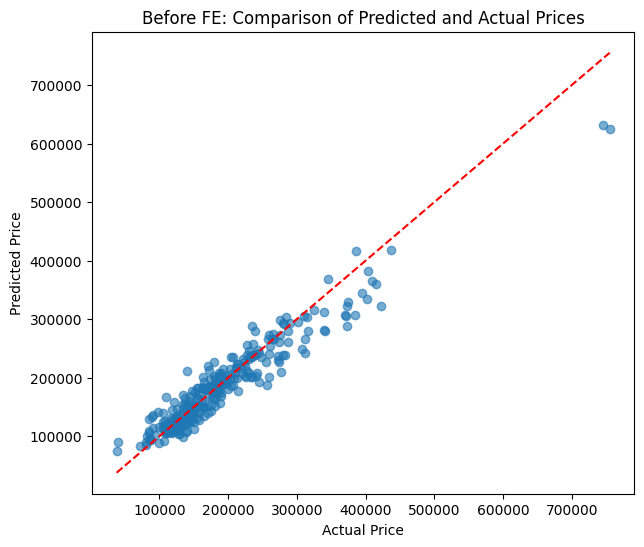

,estimator,Pipeline(step...m_state=30))])
,param_grid,{'model__alpha': array([1.0000...00000000e+01])}
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ord', ...), ...]"


In [58]:
knn_experiment(df_selected_features, title="Before FE")

##### Metric Analysis:
The Lasso Regression model performed quite well in predicting house prices. After tuning the optimal value of the regularization hyperparameter (alpha = 0.001), the metrics obtained on the test set were as follows:
- MAE ≈ 19,400 — on average, the model's predictions are off by approximately 19 thousand dollars;
- RMSE ≈ 27,300 — the average deviation of predictions from actual prices is about 27 thousand dollars.

These error values indicate that the model is capable of capturing the main relationships between the features and house prices; however, predictions can still deviate significantly from actual values. This is due to both the high variability in housing prices (different neighborhoods, quality, and additional factors) and the limited set of features used in the model.

Overall, the model successfully handled the task: it provides reasonably accurate predictions and can be used for approximate house price estimation. However, to achieve higher prediction accuracy, it would be advisable to test more complex algorithms and expand the feature set.

##### Plot Analysis:
The plot shows that the model predicts prices quite well in the mid-range ($100k–$300k); however, it tends to underestimate predictions for high-end homes (>$400k). This indicates the model's limited ability to capture extreme values, which is typical for linear models.

Performing feature engineering:

Feature selection after feature engineering:

In [59]:
df_fe = df_house_prices.copy()
df_fe["HouseAge"] = df_fe["YrSold"] - df_fe["YearBuilt"]
df_fe["RemodAge"] = df_fe["YrSold"] - df_fe["YearRemodAdd"]
df_fe["LotArea_log"] = np.log1p(df_fe["LotArea"])
df_fe["GrLivArea_log"] = np.log1p(df_fe["GrLivArea"])
df_fe["TotalBsmtSF_log"] = np.log1p(df_fe["TotalBsmtSF"])
df_fe["GarageArea_log"]  = np.log1p(df_fe["GarageArea"])
df_fe["1stFlrSF_log"] = np.log1p(df_fe["1stFlrSF"])
df_fe["HasBasement"] = (df_fe["TotalBsmtSF"] > 0).astype(int)

In [60]:
selected_features_fe = [
    "OverallQual", "GrLivArea_log", "GarageCars", "GarageArea_log", "TotalBsmtSF_log",
    "1stFlrSF_log", "FullBath", "YearBuilt", "YearRemodAdd", "HouseAge", "RemodAge", "KitchenQual",
    "Fireplaces", "Neighborhood", "LotArea_log", "ExterQual", "BsmtQual", "HasBasement"
]

In [61]:
df_selected_features_fe = df_fe[selected_features_fe + ["SalePrice"]]
df_selected_features_fe

,OverallQual,GrLivArea_log,GarageCars,GarageArea_log,TotalBsmtSF_log,1stFlrSF_log,FullBath,YearBuilt,YearRemodAdd,HouseAge,RemodAge,KitchenQual,Fireplaces,Neighborhood,LotArea_log,ExterQual,BsmtQual,HasBasement,SalePrice
0,7,7.444833,2,6.308098,6.753438,6.753438,2,2003,2003,5,5,Gd,0,CollgCr,9.042040,Gd,Gd,1,208500
1,6,7.141245,2,6.133398,7.141245,7.141245,2,1976,1976,31,31,TA,1,Veenker,9.169623,TA,Gd,1,181500
2,7,7.488294,2,6.411818,6.825460,6.825460,2,2001,2002,7,6,Gd,1,CollgCr,9.328212,Gd,Gd,1,223500
3,7,7.448916,3,6.466145,6.629363,6.869014,1,1915,1970,91,36,Gd,1,Crawfor,9.164401,TA,TA,1,140000
4,8,7.695758,3,6.729824,7.044033,7.044033,2,2000,2000,8,8,Gd,1,NoRidge,9.565284,Gd,Gd,1,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,7.407318,2,6.133398,6.860664,6.860664,2,1999,2000,8,7,TA,1,Gilbert,8.976894,TA,Gd,1,175000
1456,6,7.637234,2,6.216606,7.341484,7.637234,2,1978,1988,32,22,TA,2,NWAmes,9.486152,TA,Gd,1,210000
1457,7,7.758333,1,5.533389,7.050123,7.080868,2,1941,2006,69,4,Gd,2,Crawfor,9.109746,Ex,TA,1,266500
1458,5,6.983790,1,5.484797,6.983790,6.983790,1,1950,1996,60,14,Gd,0,NAmes,9.181735,TA,TA,1,142125


Experiment after feature engineering:


===== After FE =====
Best parameters: {'model__alpha': np.float64(0.001)}
MAE:  19314.65967338276
RMSE: 31349.0606900293


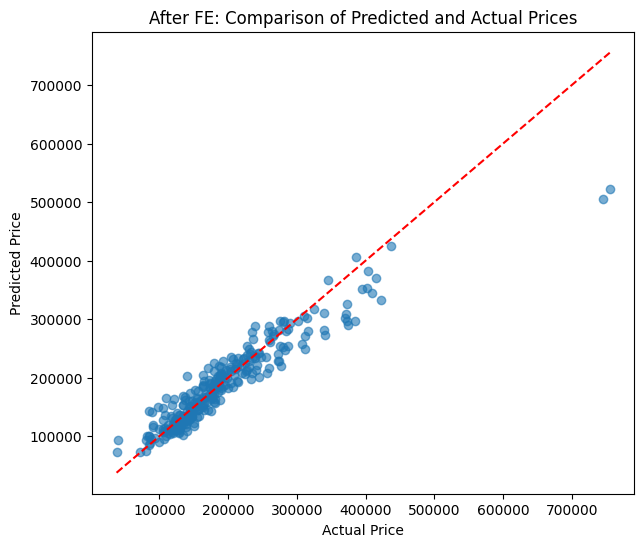

,estimator,Pipeline(step...m_state=30))])
,param_grid,{'model__alpha': array([1.0000...00000000e+01])}
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ord', ...), ...]"


In [62]:
knn_experiment(df_selected_features_fe, title="After FE")

##### Metric Analysis:
After adding new features (feature engineering), the mean absolute error (MAE) decreased from 19,408 to 19,315, indicating a slight improvement in prediction accuracy. However, the RMSE value increased from 27,304 to 31,349, meaning the model became slightly worse at handling rare large errors.

Overall, the engineered features helped the model better capture the key patterns between the features and the target variable, although its robustness to outliers decreased. This impact on RMSE highlights the need for further feature selection and potentially outlier handling to improve the model's stability.

##### Plot Analysis:
The plot shows that after adding new features, the model maintains a fairly high prediction accuracy in the mid-price range. Most predictions are close to the actual values, indicating that the model correctly captures the key relationships between the house characteristics and its price. At the same time, for high-end properties, the model tends to underestimate predicted prices, which may be due to outliers or the limitations of the linear model.